In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("WineQT.csv")  # or your file name

print(df.shape)
df.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from tensorflow.keras.layers import Dropout

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [15]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 31.6340 - mae: 5.5344 - val_loss: 24.8469 - val_mae: 4.8977
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22.4948 - mae: 4.6429 - val_loss: 16.3461 - val_mae: 3.8924
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.6325 - mae: 3.6490 - val_loss: 9.3351 - val_mae: 2.7984
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.5434 - mae: 2.6510 - val_loss: 5.2564 - val_mae: 1.9801
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8996 - mae: 1.8562 - val_loss: 3.9439 - val_mae: 1.6573
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0891 - mae: 1.6476 - val_loss: 3.4502 - val_mae: 1.5105
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3812 - mae: 1.4721 - val_loss: 3.1025 - val_mae: 1.4072
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6897 - mae: 1.4695 - val_loss: 2.8002 - val_mae: 1.3254
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss:

In [17]:
y_pred = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [18]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.42701759934425354
MAE: 0.5041931867599487


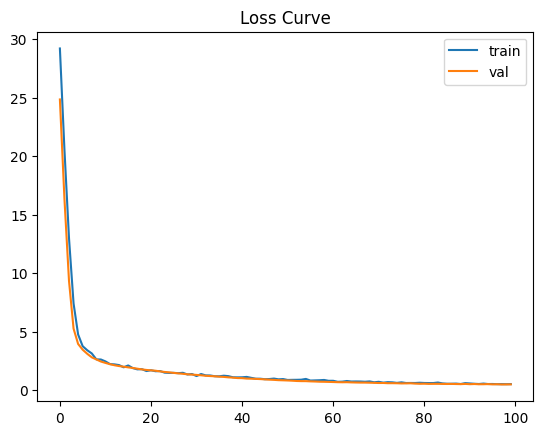

In [19]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()

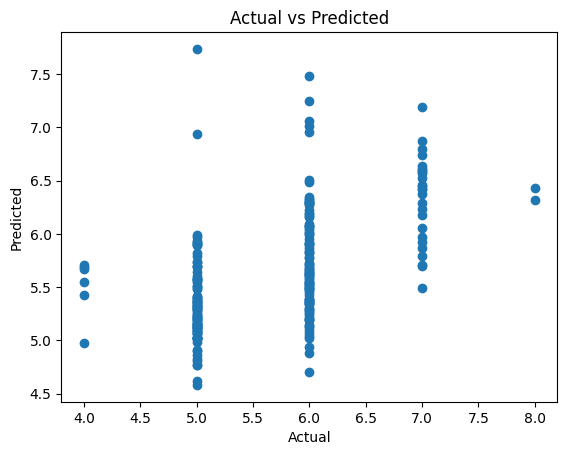

In [20]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import mean_absolute_error
print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))

LR MAE: 0.4799770439749214


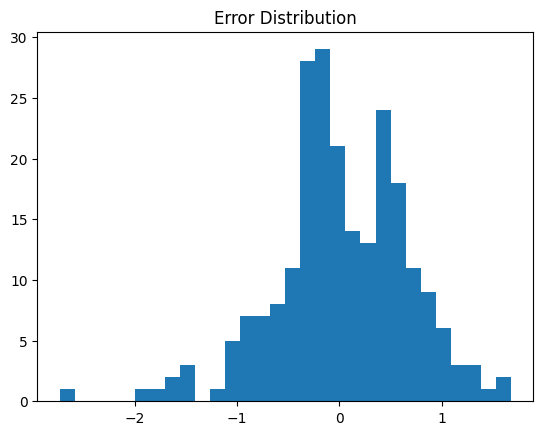

In [23]:
errors = y_test - y_pred.flatten()
plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.show()